In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path

_here = Path(os.path.abspath(""))
while not (_here / "pixi.toml").exists():
    _here = _here.parent
    if _here == _here.parent:
        raise RuntimeError("Could not find repo root")
os.chdir(_here)

In [3]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from src.experiments_analysis.sensitivity_analysis_pipeline import (
    make_config,
    run_sensitivity_analysis_multi_seed,
    build_metrics_df,
    sensitivity_barplot,
    print_chosen_alphas,
)

BASELINES_PATH = "experiments/benchmark_output_files/sensitivity_analysis/simulation_baselines.yaml"
RUNS_PATH = "experiments/benchmark_output_files/sensitivity_analysis/simulation_subsample.yaml"
cfg = make_config(BASELINES_PATH, RUNS_PATH)
output_dir = cfg["output_dir"]
figures_output_dir = Path(cfg["figures_output_dir"])
figures_output_dir.mkdir(exist_ok=True, parents=True)
Path(output_dir).mkdir(parents=True, exist_ok=True)

auto.py (21): IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
bioimageio_utils.py (2): pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


## Run analysis pipeline

In [4]:
run_sensitivity_analysis_multi_seed(cfg, synthetic_data=True)

/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/destriping/GLUM/get_metrics_dist.py:17: UserWarning: computing sol metrics for seed_42__pct_80: Metrics: 4 missing indices in h. Filling with ones.
  warnings.warn(
/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/destriping/GLUM/get_metrics_dist.py:17: UserWarning: computing sol metrics for seed_42__pct_80: Metrics: 3 missing indices in w. Filling with ones.
  warnings.warn(
/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/destriping/GLUM/get_metrics_dist.py:17: UserWarning: computing sol metrics for seed_42__pct_50: Metrics: 6 missing indices in h. Filling with ones.
  warnings.warn(
/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/destriping/GLUM/get_metrics_dist.py:17: UserWarning: computing sol metrics for seed_42__pct_50: Metrics: 6 missing indices in w. Filling with ones.
  warnings.warn(
/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/destriping/GLUM/get_

,name,distance_to_gt_poisson_sol_hw_log_euclidian,converged
21,GT_poisson_sol,0.000000,NaN
10,seed_754__pct_80,0.064912,True
6,seed_64__pct_50,0.082244,True
11,seed_754__pct_50,0.083579,True
7,seed_64__pct_25,0.096172,True
2,seed_42__pct_25,0.100470,True
12,seed_754__pct_25,0.121347,True
0,seed_42__pct_80,0.121947,True
13,seed_754__pct_10,0.149463,True
3,seed_42__pct_10,0.151686,True


/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/experiments_analysis/analysis.py:279: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  destriped_summary_df.groupby("name").apply(select_method).reset_index(drop=True)


2SN 0
GT_nbinom_sol 1
GT_poisson_sol 2
b2c-sym-c_mean 3
collapse_label 4
dividing_99_quantile 5
expected_spatial_data_wo_stripes 6
original 7
ours 8
seed_42__pct_1 9
seed_42__pct_10 10
seed_42__pct_25 11
seed_42__pct_50 12
seed_42__pct_80 13
seed_64__pct_1 14
seed_64__pct_10 15
seed_64__pct_25 16
seed_64__pct_50 17
seed_64__pct_80 18
seed_754__pct_1 19
seed_754__pct_10 20
seed_754__pct_25 21
seed_754__pct_50 22
seed_754__pct_80 23


## Results table + barplot

/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/experiments_analysis/analysis_plots.py:873: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/experiments_analysis/sensitivity_analysis_pipeline.py:883: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  data=df,


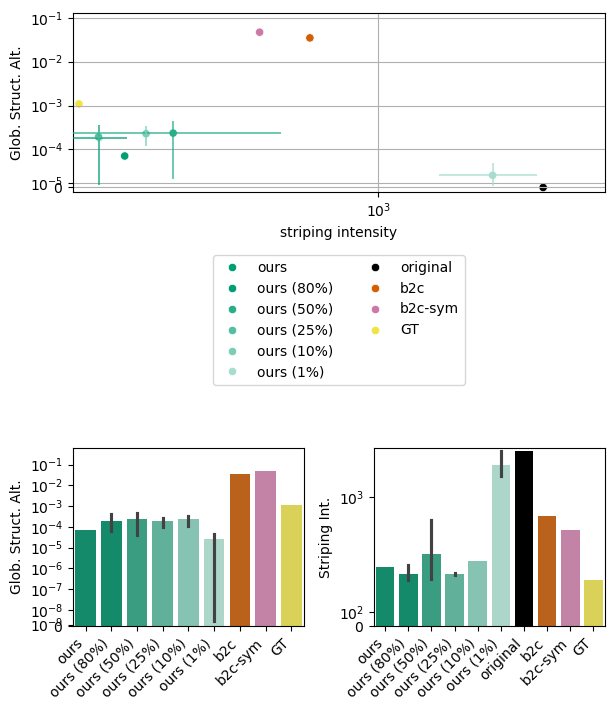

/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/experiments_analysis/analysis.py:279: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  destriped_summary_df.groupby("name").apply(select_method).reset_index(drop=True)
/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/experiments_analysis/analysis_plots.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selection["name"] = df_selection["name"].cat.remove_unused_categories()
/Users/pm

                                name  \
0                         ours (80%)   
1                         ours (80%)   
2                         ours (80%)   
3                         ours (50%)   
4                         ours (50%)   
5                         ours (50%)   
6                         ours (25%)   
7                         ours (25%)   
8                         ours (25%)   
9                         ours (10%)   
10                        ours (10%)   
11                        ours (10%)   
12                         ours (1%)   
13                         ours (1%)   
14                         ours (1%)   
15                        ours (80%)   
16                        ours (80%)   
17                        ours (80%)   
18                        ours (50%)   
19                        ours (50%)   
20                        ours (50%)   
21                        ours (25%)   
22                        ours (25%)   
23                        ours (25%)   


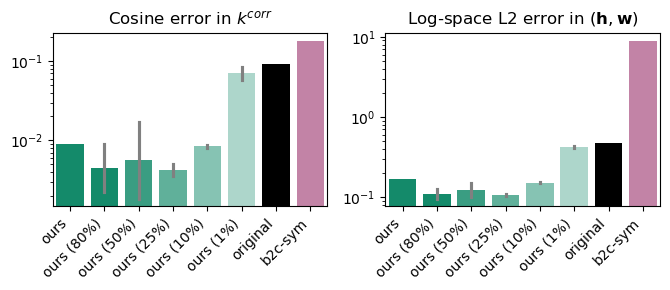

In [7]:
from src.experiments_analysis.sensitivity_analysis_pipeline import simulation_data_plots

simulation_data_plots(output_dir, figures_output_dir, "subsample")

<string>:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


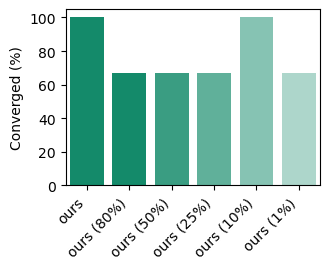

In [5]:
from src.experiments_analysis.sensitivity_analysis_pipeline import convergence_barplot

ax = convergence_barplot(output_dir, experiment_type="subsample")
plt.show()

## Chosen alpha per model

In [19]:
print_chosen_alphas(RUNS_PATH)

Chosen alpha:
seed         42        64         754
run                                  
pct_1   0.001000  0.004642  10.000000
pct_10  0.000046  0.000046   0.000215
pct_25  0.000046  0.000046   0.000215
pct_50  0.004642  0.000046   0.000010
pct_80  0.000215  0.001000   0.000010

Boundary hit wrt full CV grid (MIN / MAX / ok):
seed   42  64   754
run                
pct_1   ok  ok  MAX
pct_10  ok  ok   ok
pct_25  ok  ok   ok
pct_50  ok  ok  MIN
pct_80  ok  ok  MIN


,run,seed,alpha,grid_min,grid_max,boundary_side
0,pct_80,42,0.000215,0.00001,10.0,ok
1,pct_50,42,0.004642,0.00001,10.0,ok
2,pct_25,42,0.000046,0.00001,10.0,ok
3,pct_10,42,0.000046,0.00001,10.0,ok
4,pct_1,42,0.001000,0.00001,10.0,ok
5,pct_80,64,0.001000,0.00001,10.0,ok
6,pct_50,64,0.000046,0.00001,10.0,ok
7,pct_25,64,0.000046,0.00001,10.0,ok
8,pct_10,64,0.000046,0.00001,10.0,ok
9,pct_1,64,0.004642,0.00001,10.0,ok
